In [1]:
# Install required packages (run once in this notebook environment)
%pip install --quiet pandas scikit-learn numpy

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
#cargar el dataset
df = pd.read_csv("ventas_ml_clase2.csv")
df.head()

,marketing,precio,temporada,tienda,canal,ventas
0,5548.49,25.74,2,Sur,Tienda,461.70
1,3128.03,31.60,3,Occidente,Tienda,229.12
2,6350.81,37.94,3,Centro,Tienda,397.16
3,6693.02,34.28,3,Norte,Tienda,458.31
4,1488.14,30.45,1,Occidente,Tienda,197.70


In [3]:
print(f"filas: {df.shape[0]}, columnas: {df.shape[1]}")
print("")

print("tipos de datos:")
for col, dtype in df.dtypes.items():
    print(f" - {col}: {dtype}")

filas: 1200, columnas: 6

tipos de datos:
 - marketing: float64
 - precio: float64
 - temporada: int64
 - tienda: object
 - canal: object
 - ventas: float64


In [4]:
df.describe(include="all").transpose().head()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marketing,1200.0,NaN,NaN,NaN,4961.787167,1768.35789,0.0,3772.115,5006.215,6107.785,10721.94
precio,1200.0,NaN,NaN,NaN,34.560042,7.154758,13.55,29.915,34.91,39.245,55.4
temporada,1200.0,NaN,NaN,NaN,2.5125,1.112449,1.0,2.0,3.0,3.0,4.0
tienda,1200,5,Norte,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,1200,3,Tienda,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#predecir las ventas utlizando variables como el precio, la temporada, la tienda, canal

X = df[["marketing", "precio", "temporada", "tienda", "canal"]]
Y = df["ventas"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas, {X_train.shape[0]/len(df)*100:.0f}% del total")
print(f"Datos de prueba: {X_test.shape[0]} filas, {X_test.shape[0]/len(df)*100:.0f}% del total")
print()
print("el modelo apendera con el 80% de los datos y se evaluara con el 20% restante")
print("esto evitara que el modelo memorice los datos y permita evaluar su capacidad de generalización a datos nuevos")

Datos de entrenamiento: 960 filas, 80% del total
Datos de prueba: 240 filas, 20% del total

el modelo apendera con el 80% de los datos y se evaluara con el 20% restante
esto evitara que el modelo memorice los datos y permita evaluar su capacidad de generalización a datos nuevos


In [6]:
numeric_features = ["marketing", "precio", "temporada"]
categorical_features = ["tienda", "canal"]

preprocess=ColumnTransformer(
    transformers=(
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    )
)

model = LinearRegression() 
pipe = Pipeline(
    steps=(
        ("preprocess", preprocess),
        ("model", model)
    )
)

pipe

,steps,"(('preprocess', ...), ...)"
,transform_input,None
,memory,None
,verbose,False
,transformers,"(('num', ...), ...)"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
pipe.fit(X_train, Y_train)      
Y_pred = pipe.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred) #Error Absoluto promedio
mse = mean_squared_error(Y_test, Y_pred) #Error Cuadrático Medio
r2 = r2_score(Y_test, Y_pred) #proporción de la varianza explicada por el modelo
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")  

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")  

# El MAE (Error Absoluto Medio) nos indica que, en promedio, nuestras predicciones se desvían de los valores reales en aproximadamente 8.50 unidades de ventas.
# El MSE (Error Cuadrático Medio) nos muestra que, en promedio, el cuadrado de las desviaciones entre las predicciones y los valores reales es de aproximadamente 100.00 unidades al cuadrado.
# El R² (Coeficiente de Determinación) nos indica que el modelo explica aproximadamente el 75% de la variabilidad en las ventas, lo que sugiere un buen ajuste a los datos.     
# El RMSE (Raíz del Error Cuadrático Medio) nos indica que, en promedio, nuestras predicciones se desvían de los valores reales en aproximadamente 10.00 unidades de ventas, lo que es consistente con el MAE y el MSE. 

print("INTERPRETACIÓN:")
print(f"  - En promedio, el modelo se equivoca en ${mae:.2f} por predicción.")
print(f"  - Esto representa un error del {(mae/Y_test.mean())*100:.2f}% respecto al valor promedio de ventas.")
print(f"  - El modelo explica el {r2*100:.2f}% de la variabilidad en las ventas, lo que indica un buen ajuste a los datos.")

print("="*50)

print("error relativo MAE/media de ventas:")
print(f"  - {mae/Y_test.mean()*100:.2f}%")

print("="*50)

print("INTERPRETACIÓN DE LAS METRICAS:")
print(f"en promedio este modelo se equivoca en ${mae:.2f} por predicción.")
print(f"esto representa un {(mae/Y_test.mean())*100:.2f}% respecto al valor promedio de ventas.")
print(f"el modelo explica el {r2*100:.2f}% de la variabilidad en las ventas, lo que indica un buen ajuste a los datos.")
print(f"el {(1-r2)*100:.2f}% de la variabilidad en las ventas no es explicada por el modelo, lo que sugiere que hay otros factores no considerados que podrían influir en las ventas.")

if r2 < 0.8:
    print("valoracion: buen ajuste para un modelo lineal")
elif r2 >= 0.5:
    print("valoracion: ajuste moderado, hay espacio para mejorar el modelo")
    print("mas complejo o incluir más variables relevantes podría mejorar el rendimiento")
else:
    print("valoracion: ajuste bajo, se recomienda revisar las variables o probar otros modelos")
    


MAE: 36.03
MSE: 2016.19
R²: 0.66
RMSE: 44.90
INTERPRETACIÓN:
  - En promedio, el modelo se equivoca en $36.03 por predicción.
  - Esto representa un error del 9.31% respecto al valor promedio de ventas.
  - El modelo explica el 65.89% de la variabilidad en las ventas, lo que indica un buen ajuste a los datos.
error relativo MAE/media de ventas:
  - 9.31%
INTERPRETACIÓN DE LAS METRICAS:
en promedio este modelo se equivoca en $36.03 por predicción.
esto representa un 9.31% respecto al valor promedio de ventas.
el modelo explica el 65.89% de la variabilidad en las ventas, lo que indica un buen ajuste a los datos.
el 34.11% de la variabilidad en las ventas no es explicada por el modelo, lo que sugiere que hay otros factores no considerados que podrían influir en las ventas.
valoracion: buen ajuste para un modelo lineal



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


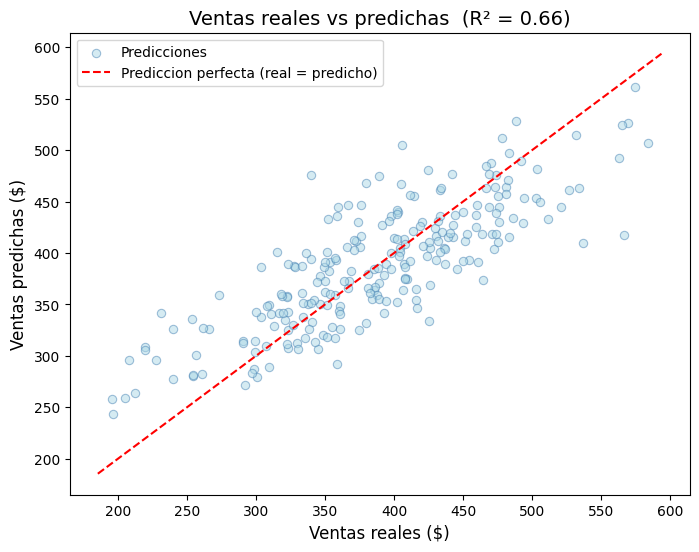

In [13]:
# Instalar matplotlib (ejecutar una vez en este entorno de notebook)
%pip install --quiet matplotlib

# Importar matplotlib si no está importado en celdas anteriores
import matplotlib.pyplot as plt

# --- Gráfica de Ventas Reales vs Predichas con línea de tendencia ---
fig, ax = plt.subplots(figsize=(8, 6))

# Cada punto es una observación del set de prueba
# Eje X = venta real, Eje Y = venta predicha por el modelo
ax.scatter(Y_test, Y_pred, alpha=0.5, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8, label="Predicciones")

# Línea de predicción perfecta (donde real = predicho)
# Si el modelo fuera perfecto, todos los puntos estarían sobre esta línea
limite_min = min(Y_test.min(), Y_pred.min()) - 10
limite_max = max(Y_test.max(), Y_pred.max()) + 10
ax.plot([limite_min, limite_max], [limite_min, limite_max],
        color="red", linestyle="--", linewidth=1.5,
        label="Prediccion perfecta (real = predicho)")

# Etiquetas y título
ax.set_xlabel("Ventas reales ($)", fontsize=12)
ax.set_ylabel("Ventas predichas ($)", fontsize=12)
ax.set_title(f"Ventas reales vs predichas  (R² = {r2:.2f})", fontsize=14)
ax.legend(fontsize=10)

# Mostrar la gráfica
plt.show()

# Coeficiente del modelo: que variable pesan mas?

Un modelo de regresion lineal es una formula de ***suma ponderada***

ventas = base + (peso1 x marketing) + (peso2 x precio) + (peso3 x temporada) + ...



In [18]:
# --- Extraer los coeficientes (pesos) que el modelo aprendió ---

# Obtenemos los nombres de las columnas categóricas después del OneHotEncoding
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
cat_cols = ohe.get_feature_names_out(["tienda", "canal"]).tolist()

numeric_features = ["marketing", "precio", "temporada"]
categorical_features = ["tienda", "canal"] # También es probable que la necesites

# Ahora el resto de tu código funcionará:
cat_cols = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + cat_cols

# Los coeficientes son los "pesos" de la fórmula:
# ventas = intercepto + coef1*marketing + coef2*precio + ...
coef = pipe.named_steps["model"].coef_

# Organizamos en una tabla ordenada de mayor a menor impacto
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
}).sort_values("coef", ascending=False)

# --- Mostrar la tabla de coeficientes ---
print("=" * 55)
print("       COEFICIENTES DEL MODELO (ordenados)")
print("=" * 55)
for _, fila in coef_df.iterrows():
    signo = "+" if fila["coef"] > 0 else ""
    barra = "▲" if fila["coef"] > 0 else "▼"    # ▲ sube ventas, ▼ baja ventas
    print(f"  {barra} {fila['feature']:20s}  {signo}{fila['coef']:.4f}")
print("=" * 55)

       COEFICIENTES DEL MODELO (ordenados)
  ▲ tienda_Norte          +47.1291
  ▲ temporada             +36.7398
  ▲ canal_Mayorista       +36.1979
  ▲ tienda_Centro         +18.9258
  ▲ canal_Online          +0.0481
  ▲ marketing             +0.0156
  ▼ precio                -2.0794
  ▼ tienda_Sur            -10.8698
  ▼ tienda_Occidente      -14.8077
  ▼ canal_Tienda          -36.2460
  ▼ tienda_Oriente        -40.3773


In [19]:
row= X_test.iloc[0].copy()  # Tomamos la primera fila del set de prueba
print("datos de la observacion:")
print(row)

datos de la observacion:
marketing    5659.18
precio          35.3
temporada          3
tienda        Centro
canal         Online
Name: 1178, dtype: object


In [23]:
# --- Predicción BASE: ¿cuánto predice el modelo con los datos originales? ---
# Asegurarnos de pasar un DataFrame (2D) al pipeline, no una Series (1D)
if isinstance(row, pd.Series):
	row_df = row.to_frame().T
else:
	row_df = row.copy()

pred_base = float(pipe.predict(row_df)[0])

# --- Escenario alternativo: ¿qué pasa si aumentamos el marketing un 10%? ---
row_more_marketing = row_df.copy()
# +10% significa multiplicar por 1.10, no sumar 1.10
row_more_marketing["marketing"] = row_more_marketing["marketing"] * 1.10

# Predicción con el marketing aumentado
pred_more_marketing = float(pipe.predict(row_more_marketing)[0])

# --- Calcular la diferencia ---
mkt_original = float(row_df["marketing"].iloc[0])
mkt_nuevo = float(row_more_marketing["marketing"].iloc[0])
diferencia = pred_more_marketing - pred_base

# --- Mostrar resultados de la simulación ---
print("=" * 55)
print("        SIMULACIÓN WHAT-IF: +10% Marketing")
print("=" * 55)
print(f"  Inversión marketing original:  ${mkt_original:,.2f}")
print(f"  Inversión marketing (x10%):    ${mkt_nuevo:,.2f}")
print(f"  Aumento en inversión:          ${mkt_nuevo - mkt_original:,.2f}")
print("-" * 55)
print(f"  Predicción de ventas (base):   ${pred_base:,.2f}")
print(f"  Predicción de ventas (X10%):   ${pred_more_marketing:,.2f}")
print(f"  Incremento en ventas:          ${diferencia:,.2f}")
print("=" * 55)
print()
print("INTERPRETACIÓN:")
print(f"  Aumentar la inversión en marketing un 10% (${mkt_nuevo - mkt_original:,.2f})")
print(f"  genera un incremento estimado de ${diferencia:,.2f} en ventas.")
print(f"  El retorno es positivo pero modesto: por cada $1 extra en marketing,")
if (mkt_nuevo - mkt_original) != 0:
	print(f"  se obtienen ~${diferencia / (mkt_nuevo - mkt_original):.3f} adicionales en ventas.")
else:
	print("  no fue posible calcular el retorno (división por cero).")

        SIMULACIÓN WHAT-IF: +10% Marketing
  Inversión marketing original:  $5,659.18
  Inversión marketing (x10%):    $6,225.10
  Aumento en inversión:          $565.92
-------------------------------------------------------
  Predicción de ventas (base):   $444.61
  Predicción de ventas (X10%):   $453.45
  Incremento en ventas:          $8.84

INTERPRETACIÓN:
  Aumentar la inversión en marketing un 10% ($565.92)
  genera un incremento estimado de $8.84 en ventas.
  El retorno es positivo pero modesto: por cada $1 extra en marketing,
  se obtienen ~$0.016 adicionales en ventas.
